<a href="https://colab.research.google.com/github/nwanze-nzekwu/turinCE/blob/main/Rafael_FSO_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import pandas as pd
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RandomForestRegressor
from sklearn.metrics import root_mean_squared_error as rmse


In [5]:
# Some functions

# Moving Average
def moving_average(data, window_size):
  x = data
  N = window_size
  moving_avg = np.zeros(len(x))
  for n in range(len(x)):
    if n < N:
      x_n = x[:n + 1]
    else:
      x_n = x[n - N + 1:n + 1]
    moving_avg[n] = np.sum(x_n) / len(x_n)
  return moving_avg

# Pow2db
def pow2db(x):
  return 10*np.log10(x)

# db2pow
def dbm_to_watts(power_dBm):
  power_watts = 10**((power_dBm - 30) / 10)
  return


In [6]:
wan_data = sio.loadmat('lin_wan5_strong_turb_samps.mat')
wa = wan_data['lin_wan5_s_dat'][:1000000]
turb = 'strong'

# wan_data = sio.loadmat('lin_wan5_mod_turb_samps.mat')
# wa = wan_data['lin_wan5_m_dat'][:1000000]
# turb = 'moderate'

# wan_data = sio.loadmat('lin_wan5_weak_turb_samps.mat')
# wa = wan_data['lin_wan5_w_dat'][:1000000]
# turb = 'weak'

wa = pow2db(wa) - np.mean(pow2db(wa))

nTaps = 10

latency = 10; # 50

use_diff = True

In [7]:
df = pd.DataFrame(wa)
df.columns = ['OptPow']
df2 = df.copy()

In [8]:
#Defining system latency in samples

# Adding the diff steps
df2['OptPow_diff'] = df2['OptPow'].diff()

# Adding lagged features
for lag in range(latency,latency+nTaps):
  df2['OptPow_diff_lag' + str(lag)] = df2['OptPow_diff'].shift(lag)

# Adding the target variable
df2['OptPow_lag'+str(latency)] = df2['OptPow'].shift(latency)
df2['OptPow_'+str(latency)+'stepdiff_target'] = df2['OptPow']-df2['OptPow_lag'+str(latency)]

# Dropping invalid rows due to lags
df2.dropna(inplace=True)

In [9]:
df2.head()

,OptPow,OptPow_diff,OptPow_diff_lag10,OptPow_diff_lag11,OptPow_diff_lag12,OptPow_diff_lag13,OptPow_diff_lag14,OptPow_diff_lag15,OptPow_diff_lag16,OptPow_diff_lag17,OptPow_diff_lag18,OptPow_diff_lag19,OptPow_lag10,OptPow_10stepdiff_target
20,10.329545,-0.0712,0.1246,0.1602,0.1424,0.1780,0.1780,0.1780,0.2136,0.1780,0.2314,0.1780,9.848945,0.4806
21,10.347345,0.0178,0.1246,0.1246,0.1602,0.1424,0.1780,0.1780,0.1780,0.2136,0.1780,0.2314,9.973545,0.3738
22,10.276145,-0.0712,0.1068,0.1246,0.1246,0.1602,0.1424,0.1780,0.1780,0.1780,0.2136,0.1780,10.080345,0.1958
23,10.240545,-0.0356,0.0712,0.1068,0.1246,0.1246,0.1602,0.1424,0.1780,0.1780,0.1780,0.2136,10.151545,0.0890
24,10.169345,-0.0712,0.0712,0.0712,0.1068,0.1246,0.1246,0.1602,0.1424,0.1780,0.1780,0.1780,10.222745,-0.0534


In [10]:
# df2.describe()

In [11]:
# test_size=0.2
# df2_train = df2[:round((1-test_size)*len(df2))]
# df2_test = df2[round((1-test_size)*len(df2)):]

# Instead of 80/20 %, Use less training samples, closer to real life scenario #######
nTrain = 10000
nTest = 1000

df2_train = df2[:nTrain]
df2_test = df2[nTrain:]


In [12]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


TRAINING

In [13]:
# Define the feature columns and target column
feature_columns = ['OptPow_diff_lag'+str(i) for i in range(latency,latency+nTaps)]
target_column = 'OptPow_'+str(latency)+'stepdiff_target'

# Separate the features and target variables
X_train = df2_train[feature_columns]
y_train = df2_train[target_column]

X_test = df2_test[feature_columns]
y_test = df2_test[target_column]


In [14]:

# Test CATBOOST
from catboost import CatBoostRegressor
model_cb = CatBoostRegressor(iterations=788,
                          depth=8,
                          l2_leaf_reg=1.0116320759542563,
                          rsm=0.7030000000000001,
                          logging_level='Silent',
                          feature_border_type='GreedyLogSum',
                          fold_permutation_block=1,
                          od_type='IncToDec',
                          nan_mode='Min',
                          max_ctr_complexity=4,
                          has_time=False,
                          allow_const_label=False,
                          random_strength=1.0,
                          final_ctr_computation_mode='Default',
                          score_function='Cosine',
                          leaf_estimation_backtracking='AnyImprovement',
                          bootstrap_type='MVS')

model_cb.fit(X_train, y_train)

predictions_cb = model_cb.predict(X_test)+df2_test['OptPow_lag'+str(latency)]



In [15]:
# Random Forest
model_r_forest = RandomForestRegressor()
model_r_forest.fit(X_train, y_train)
predictions_rf = model_r_forest.predict(X_test)+df2_test['OptPow_lag'+str(latency)]


# Test NAIVE (a.k.a ZOH). Assume the prediction is equal to the last value
predictions_naive = df2_test['OptPow_lag'+str(latency)]


# Test LINEAR REGRESSION
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

predictions_lr = model_lr.predict(X_test)+df2_test['OptPow_lag'+str(latency)]


In [16]:
# Define Least Mean Square function.

def myPytLMS_adapted(x_input, d_target, N, w=None, lock_coeff=False):

  X = x_input.values
  d = d_target.values
  # N is the number of taps

  L = len(X)  # Number of data points

  # Initialize outputs
  if w is None:
      w = np.zeros(N)  # Default: Initialize weights to zero

  e = np.zeros(L)
  y = np.zeros(L)
  wts = np.zeros((L, N))
  mu = 1e-5  # Learning rate

  # LMS Algorithm Iteration
  for n in range(L):
      # Input segment (row of lagged features)
      x_n = X[n, :]

      # Calculate predicted output
      y[n] = np.dot(w, x_n)

      # Calculate error
      e[n] = d[n] - y[n]

      # Update weights if lock_coeff is False
      if not lock_coeff:
          w = w + (mu) * e[n] * x_n  # Simplified update rule

      # Store weights for analysis
      wts[n, :] = w

  return y, e, wts

In [17]:
# Train and test LMS

ylms_train,elms,wlms = myPytLMS_adapted(X_train, y_train, nTaps, w=None, lock_coeff=False)
w=wlms[-1,:]  # modify w to use the last weights when lock_coeff = True
ylms_test,_,wlms2 = myPytLMS_adapted(X_test, y_test, nTaps, w=wlms[-1,:], lock_coeff=True)

predictions_lms = ylms_test + df2_test['OptPow_lag'+str(latency)]

RMSE of Naive: 3.932225262975534
RMSE of LR: 3.483652784595476
RMSE of CB: 2.200082028633371
RMSE of RF: 2.2474625418862377
RMSE of LMS: 3.8889807827575673


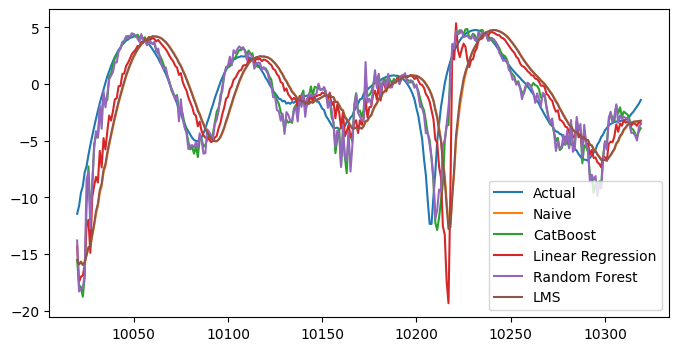

In [18]:
plt.figure(figsize=(8, 4))
pdIdx = 300
plt.plot(df2_test['OptPow'][:pdIdx], label='Actual') # Actual
plt.plot(predictions_naive[:pdIdx], label='Naive')   # Naive
plt.plot(predictions_cb[:pdIdx], label='CatBoost')   # CatBoost
plt.plot(predictions_lr[:pdIdx], label='Linear Regression')  # Linear Regression
plt.plot(predictions_rf[:pdIdx], label='Random Forest')  # Linear Regression
plt.plot(predictions_lms[:pdIdx], label='LMS')  # LMS
plt.legend()

print(f"RMSE of Naive: {rmse(df2_test['OptPow'],predictions_naive)}")
print(f"RMSE of LR: {rmse(df2_test['OptPow'],predictions_lr)}")
print(f"RMSE of CB: {rmse(df2_test['OptPow'],predictions_cb)}")
print(f"RMSE of RF: {rmse(df2_test['OptPow'],predictions_rf)}")
print(f"RMSE of LMS: {rmse(df2_test['OptPow'],predictions_lms)}")

FEATURES IMPORTANCE

In [19]:
# print("Feature Importance in Linear Regression:")
# for feature_name, importance in zip(feature_columns, model_lr.coef_):
#     print(feature_name, ":", importance)

# print("Feature Importance in CatBoost:")
# for feature_name, importance in zip(feature_columns, model_cb.feature_importances_):
#     print(feature_name, ":", importance)

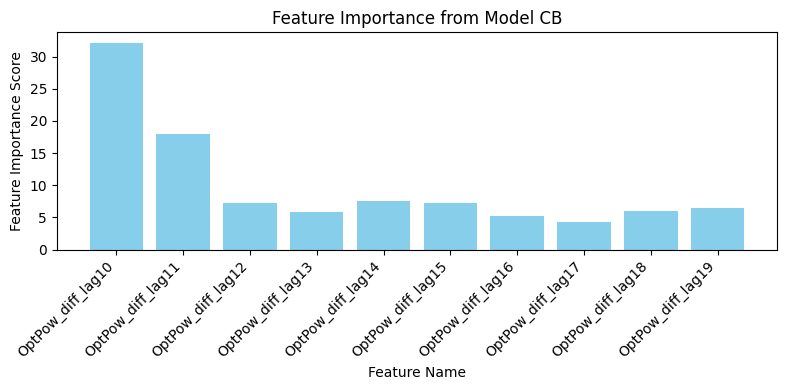

In [20]:

features = []
importances = []

for feature_name, importance in zip(feature_columns, model_cb.feature_importances_):
    features.append(feature_name)
    importances.append(importance)

# 2. Create the Bar Chart
plt.figure(figsize=(8, 4))

# Use plt.bar() to create the visualization
plt.bar(features, importances, color='skyblue')

# Add labels and title for clarity
plt.xlabel("Feature Name")
plt.ylabel("Feature Importance Score")
plt.title("Feature Importance from Model CB")

# Rotate feature labels for better readability if names are long
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

**TESTING/PREDICTION, FOR RANGE OF LATENCIES** (*Without updating coefficients*)

In [21]:
# Repeat for a range of latencies
test_latencies = [1, 5, 10, 15, 20, 25, 30, 35, 40, 50]

rmse_naive = []
rmse_lr = []
rmse_cb = []
rmse_rf = []
rmse_lms = []

var_cb = []
var_lr = []
var_naive = []
var_rf = []
var_input = []
var_lms = []

p_cb = []
p_lr = []
p_naive = []
p_rf = []
p_lms = []

for latency in test_latencies:
  df2 = df.copy()

  # Adding the diff steps
  df2['OptPow_diff'] = df2['OptPow'].diff()

  # Adding lagged features
  for lag in range(latency,latency+nTaps):
    df2['OptPow_diff_lag' + str(lag)] = df2['OptPow_diff'].shift(lag)

  # Adding the target variable, the step nTaps samples from now:
  df2['OptPow_lag'+str(latency)] = df2['OptPow'].shift(latency)

  df2['OptPow_'+str(latency)+'stepdiff_target'] = df2['OptPow']-df2['OptPow_lag'+str(latency)]

  # Dropping invalid rows due to lags
  df2.dropna(inplace=True)


  # Split train/test
  #test_size=0.2
  #df2_train = df2[:round((1-test_size)*len(df2))]
  #df2_test = df2[round((1-test_size)*len(df2)):]

  # Use Train and Test samples similar to LMS
  nTrain = 10000
  nTest = 10000
  df2_train = df2[:nTrain]
  df2_test = df2[nTrain:]

  # Define the feature columns and target column
  feature_columns = ['OptPow_diff_lag'+str(i) for i in range(latency,latency+nTaps)]
  target_column = 'OptPow_'+str(latency)+'stepdiff_target'

  # Separate the features and target variables
  X_train = df2_train[feature_columns]
  y_train = df2_train[target_column]
  X_test = df2_test[feature_columns]
  y_test = df2_test[target_column]


  # Test Naive (this assumes the prediction is equal to the last value)
  predictions_naive = df2_test['OptPow_lag'+str(latency)]


  # TRAIN & TEST LINEAR REGRESSION
  model_lr.fit(X_train, y_train)
  predictions_lr = model_lr.predict(X_test)+df2_test['OptPow_lag'+str(latency)]


  # TRAIN & TEST CATBOOST
  model_cb.fit(X_train, y_train)

  predictions_cb = model_cb.predict(X_test)+df2_test['OptPow_lag'+str(latency)]


  # TRAIN & TEST RANDOM FOREST
  model_r_forest.fit(X_train, y_train)
  predictions_rf = model_r_forest.predict(X_test)+df2_test['OptPow_lag'+str(latency)]


   # TRAIN & TEST LMS
  ylms_train,elms,wlms = myPytLMS_adapted(X_train, y_train, nTaps, w=None, lock_coeff=False)
  w=wlms[-1,:]  # modify w to use the last weights when lock_coeff = True
  ylms_test,_,wlms2 = myPytLMS_adapted(X_test, y_test, nTaps, w=wlms[-1,:], lock_coeff=True)
  predictions_lms = ylms_test + df2_test['OptPow_lag'+str(latency)]



  # Evaluate RMSE
  rmse_naive +=[rmse(df2_test['OptPow'],predictions_naive)]
  rmse_lr +=[rmse(df2_test['OptPow'],predictions_lr)]
  rmse_cb +=[rmse(df2_test['OptPow'],predictions_cb)]
  rmse_rf +=[rmse(df2_test['OptPow'],predictions_rf)]
  rmse_lms +=[rmse(df2_test['OptPow'],predictions_lms)]


  # Pre-compensate power.
  precom_cb = df2_test['OptPow'] - predictions_cb # Catboost
  precom_lr = df2_test['OptPow'] - predictions_lr # Linear Regression
  precom_naive = df2_test['OptPow'] - predictions_naive # Naive
  precom_rf = df2_test['OptPow'] - predictions_rf # Random Forest
  precom_lms = df2_test['OptPow'] - predictions_lms # LMS


  # Variance of Pre-compensated power
  var_cb += [np.var(precom_cb)]
  var_lr += [np.var(precom_lr)]
  var_naive += [np.var(precom_naive)]
  var_rf += [np.var(precom_rf)]
  var_input = np.var(df2_test['OptPow'])
  var_lms += [np.var(precom_lms)]

  p_cb += [precom_cb]
  p_lr += [precom_lr]
  p_naive += [precom_naive]
  p_rf += [precom_rf]
  p_lms += [precom_lms]


PLOT EVALUATION METRICS

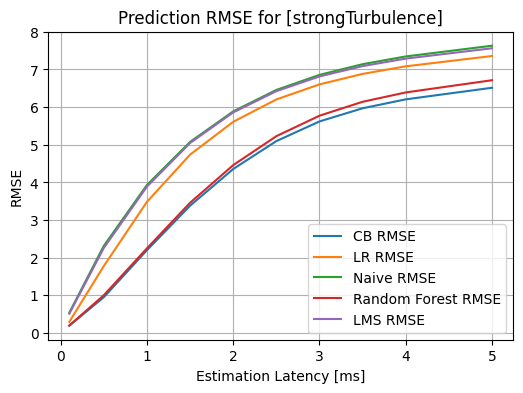

In [22]:
# Plot RMSE

plt.figure(figsize=(6, 4))
# plt.axhline(y=var_input, label='Input Variance', linestyle='--')

tl = np.array(test_latencies)/10

plt.plot(tl, rmse_cb, label='CB RMSE')
plt.plot(tl, rmse_lr, label='LR RMSE')
plt.plot(tl, rmse_naive, label='Naive RMSE')
plt.plot(tl, rmse_rf, label='Random Forest RMSE')
plt.plot(tl, rmse_lms, label='LMS RMSE')
plt.legend()
plt.xlabel('Estimation Latency [ms]')
plt.ylabel('RMSE')
plt.title('Prediction RMSE for [' + turb + 'Turbulence]');
plt.grid()

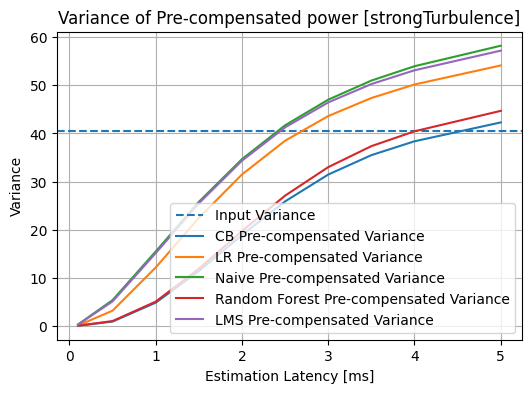

In [23]:
# Plot VARIANCE

plt.figure(figsize=(6, 4))
plt.axhline(y=var_input, label='Input Variance', linestyle='--')

plt.plot(tl, var_cb, label='CB Pre-compensated Variance')
plt.plot(tl, var_lr, label='LR Pre-compensated Variance')
plt.plot(tl, var_naive, label='Naive Pre-compensated Variance')
plt.plot(tl, var_rf, label='Random Forest Pre-compensated Variance')
plt.plot(tl, var_lms, label='LMS Pre-compensated Variance')
plt.legend()
plt.xlabel('Estimation Latency [ms]')
plt.ylabel('Variance')
plt.title('Variance of Pre-compensated power [' + turb + 'Turbulence]');
plt.grid()